# NCAA March Mania 2026 â€” Integrated Model

**Base model:** XGBoost regression on point differential, box score averages, GLM quality, spline calibration.

**Enhancements integrated:**

1. Improved Elo engine â€” home court advantage, margin-of-victory multiplier, season regression
2. Rich Elo-derived features â€” elo_vs_peak, trends, strength of schedule, behavioral win rates
3. Massey ordinal ratings (POM, SAG, MOR, WLK) for men's teams
4. Elo-Massey divergence signal


## 1. Load Data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import re

from scipy.stats import linregress

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)
data_dir = "data/"

M_regular_results = pd.read_csv(f"{data_dir}MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}WNCAATourneySeeds.csv")

# Massey ordinals (men only)
massey = pd.read_csv(f"{data_dir}MMasseyOrdinals.csv")

# Conference tourney games â€” no scores, so used for features only (not Elo)
M_conf_tourney_games = pd.read_csv(f"{data_dir}MConferenceTourneyGames.csv")
W_conf_tourney_games = pd.read_csv(f"{data_dir}WConferenceTourneyGames.csv")

regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

season = 2003
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]

print(f"Men regular season games: {len(M_regular_results):,}")
print(f"Women regular season games: {len(W_regular_results):,}")
print(f"Men conf tourney games: {len(M_conf_tourney_games):,}")
print(f"Women conf tourney games: {len(W_conf_tourney_games):,}")
print(f"Massey file rows: {len(massey):,}")

Men regular season games: 124,529
Women regular season games: 87,187
Men conf tourney games: 7,093
Women conf tourney games: 6,777
Massey file rows: 5,865,001


## 2. Prepare Data

Each game is entered twice â€” once with Team A as T1 and once with Team B as T1 â€” so the model sees both perspectives symmetrically.


In [2]:
def prepare_data(df):
    df = df[
        [
            "Season",
            "DayNum",
            "LTeamID",
            "LScore",
            "WTeamID",
            "WScore",
            "NumOT",
            "LFGM",
            "LFGA",
            "LFGM3",
            "LFGA3",
            "LFTM",
            "LFTA",
            "LOR",
            "LDR",
            "LAst",
            "LTO",
            "LStl",
            "LBlk",
            "LPF",
            "WFGM",
            "WFGA",
            "WFGM3",
            "WFGA3",
            "WFTM",
            "WFTA",
            "WOR",
            "WDR",
            "WAst",
            "WTO",
            "WStl",
            "WBlk",
            "WPF",
        ]
    ]

    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = [
        "LScore",
        "WScore",
        "LFGM",
        "LFGA",
        "LFGM3",
        "LFGA3",
        "LFTM",
        "LFTA",
        "LOR",
        "LDR",
        "LAst",
        "LTO",
        "LStl",
        "LBlk",
        "LPF",
        "WFGM",
        "WFGA",
        "WFGM3",
        "WFGA3",
        "WFTM",
        "WFTA",
        "WOR",
        "WDR",
        "WAst",
        "WTO",
        "WStl",
        "WBlk",
        "WPF",
    ]
    for col in adjcols:
        df[col] = df[col] / adjot

    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [
        x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)
    ]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (
        output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))
    ) * 1
    return output


regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

## 3. Feature Engineering â€” Seeds


In [3]:
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))

seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[
    ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]
]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

## 4. Feature Engineering â€” Box Score Averages


In [4]:
boxcols = [
    "T1_Score",
    "T1_FGM",
    "T1_FGA",
    "T1_FGM3",
    "T1_FGA3",
    "T1_FTM",
    "T1_FTA",
    "T1_OR",
    "T1_DR",
    "T1_Ast",
    "T1_TO",
    "T1_Stl",
    "T1_Blk",
    "T1_PF",
    "T2_Score",
    "T2_FGM",
    "T2_FGA",
    "T2_FGM3",
    "T2_FGA3",
    "T2_FTM",
    "T2_FTA",
    "T2_OR",
    "T2_DR",
    "T2_Ast",
    "T2_TO",
    "T2_Stl",
    "T2_Blk",
    "T2_PF",
    "PointDiff",
]

ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = [
    "T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_")
    for x in list(ss_T1.columns)
]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = [
    "T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_")
    for x in list(ss_T2.columns)
]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")

## 5. Feature Engineering Enhanced Elo Rating System

Upgraded from the base model's simple Elo (K=100, no adjustments) to a richer system:

- **K=30** â€” less volatile, more stable ratings
- **Home court advantage** (+100 Elo points) â€” adjusts expected probability
- **Margin of victory multiplier** â€” `clip(1 + margin/15, 0.5, 3.0)` â€” winning by 25 means more than winning by 1
- **Season regression** â€” ratings pulled 25% toward baseline each new season (roster turnover)
- **Game-by-game log** â€” enables trajectory features (elo_vs_peak, trends, schedule quality)

**Leakage fix:** Elo is computed from regular season games only. Tournament games are NOT included in the rating updates used for features â€” otherwise `elo_last` would contain post-tournament information, leaking outcomes into the prediction target.


In [5]:
ELO_INIT = 1500
ELO_K = 30
ELO_HCA = 100
ELO_REG = 0.75


def compute_elo(regular_df):
    """Compute Elo ratings from regular season games only (no leakage)."""
    all_games = (
        regular_df.copy().sort_values(["Season", "DayNum"]).reset_index(drop=True)
    )
    elo = {}
    season_end = {}
    game_log = []
    prev_season = None

    for _, row in all_games.iterrows():
        s = row["Season"]
        w_id, l_id = row["WTeamID"], row["LTeamID"]
        loc = row.get("WLoc", "N")

        if s != prev_season:
            if prev_season is not None:
                for tid, r in elo.items():
                    season_end[(prev_season, tid)] = r
                elo = {
                    tid: ELO_REG * r + (1 - ELO_REG) * ELO_INIT
                    for tid, r in elo.items()
                }
            prev_season = s

        r_w = elo.get(w_id, ELO_INIT)
        r_l = elo.get(l_id, ELO_INIT)
        r_w_adj = r_w + (ELO_HCA if loc == "H" else (-ELO_HCA if loc == "A" else 0))
        exp_w = 1.0 / (1.0 + 10 ** ((r_l - r_w_adj) / 400.0))
        mov = np.clip(1 + (row["WScore"] - row["LScore"]) / 15, 0.5, 3.0)

        game_log.append(
            {
                "Season": s,
                "DayNum": row["DayNum"],
                "WTeamID": w_id,
                "LTeamID": l_id,
                "WScore": row["WScore"],
                "LScore": row["LScore"],
                "WLoc": loc,
                "r_w_pre": r_w,
                "r_l_pre": r_l,
                "exp_w": exp_w,
                "margin": row["WScore"] - row["LScore"],
            }
        )

        elo[w_id] = r_w + ELO_K * mov * (1.0 - exp_w)
        elo[l_id] = r_l + ELO_K * mov * (0.0 - (1.0 - exp_w))

    if prev_season:
        for tid, r in elo.items():
            season_end[(prev_season, tid)] = r

    return season_end, pd.DataFrame(game_log)


print("Running Elo engine (regular season only)...")
elo_end_m, log_m = compute_elo(M_regular_results)
elo_end_w, log_w = compute_elo(W_regular_results)
print(f"Done. Men: {len(log_m):,} games | Women: {len(log_w):,} games")

Running Elo engine (regular season only)...
Done. Men: 124,529 games | Women: 87,187 games


### Elo-derived features

From the game-by-game log we extract richer signals than just end-of-season rating:

| Feature                | What it captures                                         |
| ---------------------- | -------------------------------------------------------- |
| `elo_last`             | End-of-season rating â€” current strength                |
| `elo_vs_peak`          | How far from season high â€” are they peaking or fading? |
| `elo_trend`            | Full-season rating slope â€” overall trajectory          |
| `elo_late_trend`       | Feb+ rating slope â€” late-season momentum               |
| `strength_of_schedule` | Average pre-game opponent Elo                            |
| `quality_of_wins`      | Average Elo of opponents beaten                          |
| `win_rate_as_fav`      | Consistency when favored                                 |
| `win_rate_as_dog`      | Upset ability                                            |
| `close_game_win_rate`  | Composure in tight games (â‰¤5 pts)                      |
| `neutral_win_rate`     | Performance on neutral courts (tournament proxy)         |


In [6]:
def build_elo_features(game_log, elo_end_dict):
    """Build rich per-team-season features from Elo game log.
    Game log already contains only regular season games (no tourney leakage)."""
    log = game_log.copy()
    records = []

    for s in sorted(log["Season"].unique()):
        sg = log[log["Season"] == s]
        teams = set(sg["WTeamID"].tolist() + sg["LTeamID"].tolist())

        for tid in teams:
            won = sg[sg["WTeamID"] == tid]
            lost = sg[sg["LTeamID"] == tid]
            n_wins, n_losses = len(won), len(lost)
            n_games = n_wins + n_losses
            if n_games == 0:
                continue

            # Elo trajectory
            elo_w = won[["DayNum", "r_w_pre"]].rename(columns={"r_w_pre": "elo"})
            elo_l = lost[["DayNum", "r_l_pre"]].rename(columns={"r_l_pre": "elo"})
            te = pd.concat([elo_w, elo_l]).sort_values("DayNum")
            ev = te["elo"].values

            elo_last = elo_end_dict.get((s, tid), ELO_INIT)
            elo_mean = ev.mean()
            elo_std = ev.std() if len(ev) > 1 else 0
            elo_vs_peak = elo_last - ev.max()

            late = te[te["DayNum"] > 100]
            elo_late_trend = (
                linregress(range(len(late)), late["elo"].values)[0]
                if len(late) >= 3
                else 0
            )
            elo_trend = linregress(range(len(ev)), ev)[0] if len(ev) >= 3 else 0

            # Schedule quality (pre-game opponent Elo to avoid leakage)
            all_opp = np.concatenate([won["r_l_pre"].values, lost["r_w_pre"].values])
            sos = all_opp.mean() if len(all_opp) > 0 else ELO_INIT
            qow = won["r_l_pre"].mean() if n_wins > 0 else ELO_INIT

            # Behavioral rates
            fav_wins = (won["r_w_pre"] > won["r_l_pre"]).sum()
            dog_wins = (won["r_w_pre"] < won["r_l_pre"]).sum()
            fav_games = fav_wins + (lost["r_l_pre"] > lost["r_w_pre"]).sum()
            dog_games = dog_wins + (lost["r_l_pre"] < lost["r_w_pre"]).sum()
            wraf = fav_wins / fav_games if fav_games > 0 else 0.5
            wrad = dog_wins / dog_games if dog_games > 0 else 0.0

            c_won = (won["margin"].abs() <= 5).sum()
            c_lost = (lost["margin"].abs() <= 5).sum()
            cgwr = c_won / (c_won + c_lost) if (c_won + c_lost) > 0 else 0.5

            n_won = won[won["WLoc"] == "N"]
            n_lost = lost[lost["WLoc"] == "N"]
            nn = len(n_won) + len(n_lost)
            nwr = len(n_won) / nn if nn > 0 else n_wins / n_games

            records.append(
                {
                    "Season": s,
                    "TeamID": tid,
                    "elo_last": elo_last,
                    "elo_mean": elo_mean,
                    "elo_std": elo_std,
                    "elo_trend": elo_trend,
                    "elo_late_trend": elo_late_trend,
                    "elo_vs_peak": elo_vs_peak,
                    "strength_of_schedule": sos,
                    "quality_of_wins": qow,
                    "win_rate_as_fav": wraf,
                    "win_rate_as_dog": wrad,
                    "close_game_win_rate": cgwr,
                    "neutral_win_rate": nwr,
                }
            )

    return pd.DataFrame(records)


elo_feats_m = build_elo_features(log_m, elo_end_m)
elo_feats_w = build_elo_features(log_w, elo_end_w)
elo_features = pd.concat([elo_feats_m, elo_feats_w], ignore_index=True)

In [7]:
elo_cols = [c for c in elo_features.columns if c not in ["Season", "TeamID"]]

elo_T1 = elo_features.copy()
elo_T1.columns = ["Season", "T1_TeamID"] + [f"T1_{c}" for c in elo_cols]

elo_T2 = elo_features.copy()
elo_T2.columns = ["Season", "T2_TeamID"] + [f"T2_{c}" for c in elo_cols]

tourney_data = pd.merge(tourney_data, elo_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elo_T2, on=["Season", "T2_TeamID"], how="left")

# Compute diffs for key Elo features
tourney_data["elo_diff"] = tourney_data["T1_elo_last"] - tourney_data["T2_elo_last"]
tourney_data["elo_vs_peak_diff"] = (
    tourney_data["T1_elo_vs_peak"] - tourney_data["T2_elo_vs_peak"]
)
tourney_data["elo_trend_diff"] = (
    tourney_data["T1_elo_trend"] - tourney_data["T2_elo_trend"]
)
tourney_data["elo_late_trend_diff"] = (
    tourney_data["T1_elo_late_trend"] - tourney_data["T2_elo_late_trend"]
)
tourney_data["sos_diff"] = (
    tourney_data["T1_strength_of_schedule"] - tourney_data["T2_strength_of_schedule"]
)
tourney_data["qow_diff"] = (
    tourney_data["T1_quality_of_wins"] - tourney_data["T2_quality_of_wins"]
)
tourney_data["neutral_wr_diff"] = (
    tourney_data["T1_neutral_win_rate"] - tourney_data["T2_neutral_win_rate"]
)
tourney_data["close_game_wr_diff"] = (
    tourney_data["T1_close_game_win_rate"] - tourney_data["T2_close_game_win_rate"]
)

## 6. Feature Engineering Massey Ordinals

Expert ranking systems (POM, SAG, MOR, WLK) available for men's teams from 2003 onward. These capture efficiency-based and schedule-adjusted signals that Elo may miss.


In [8]:
SYSTEMS = ["POM", "SAG", "MOR", "WLK"]

massey_pre = (
    massey[massey["SystemName"].isin(SYSTEMS) & (massey["RankingDayNum"] <= 128)]
    .sort_values(["Season", "TeamID", "SystemName", "RankingDayNum"])
    .groupby(["Season", "TeamID", "SystemName"])
    .last()
    .reset_index()
)

massey_pivot = massey_pre.pivot_table(
    index=["Season", "TeamID"], columns="SystemName", values="OrdinalRank"
).reset_index()
massey_pivot.columns.name = None

massey_score_cols = []
for s in SYSTEMS:
    if s in massey_pivot.columns:
        col = f"massey_{s.lower()}"
        massey_pivot[col] = 400 - massey_pivot[s]
        massey_score_cols.append(col)
        massey_pivot.drop(columns=s, inplace=True)

massey_pivot["massey_consensus"] = massey_pivot[massey_score_cols].mean(axis=1)
massey_score_cols.append("massey_consensus")

# Merge for T1 and T2
massey_T1 = massey_pivot[["Season", "TeamID"] + massey_score_cols].copy()
massey_T1.columns = ["Season", "T1_TeamID"] + [f"T1_{c}" for c in massey_score_cols]

massey_T2 = massey_pivot[["Season", "TeamID"] + massey_score_cols].copy()
massey_T2.columns = ["Season", "T2_TeamID"] + [f"T2_{c}" for c in massey_score_cols]

tourney_data = pd.merge(tourney_data, massey_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, massey_T2, on=["Season", "T2_TeamID"], how="left")

tourney_data["massey_consensus_diff"] = (
    tourney_data["T1_massey_consensus"] - tourney_data["T2_massey_consensus"]
)

# Elo-Massey divergence: normalize within season, compute gap
# This signal captures teams whose Elo is inflated relative to expert assessment
for col_pair in [
    ("T1_elo_last", "T1_massey_consensus", "T1_elo_massey_divergence"),
    ("T2_elo_last", "T2_massey_consensus", "T2_elo_massey_divergence"),
]:
    elo_col, massey_col, div_col = col_pair
    elo_norm = tourney_data.groupby("Season")[elo_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5
    )
    massey_norm = tourney_data.groupby("Season")[massey_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5
    )
    tourney_data[div_col] = elo_norm - massey_norm

tourney_data["elo_massey_div_diff"] = tourney_data["T1_elo_massey_divergence"].fillna(
    0
) - tourney_data["T2_elo_massey_divergence"].fillna(0)

## 7. Feature Engineering GLM Team Quality

GLM estimates team quality simultaneously from all games in a season using a linear model: `PointDiff ~ T1_TeamID + T2_TeamID`. This captures overall team strength adjusted for opponent quality in a single pass.


In [9]:
import statsmodels.api as sm
import tqdm

regular_data["ST1"] = regular_data.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1
)
regular_data["ST2"] = regular_data.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1
)
seeds_T1["ST1"] = seeds_T1.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1
)
seeds_T2["ST2"] = seeds_T2.apply(
    lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1
)

st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
st = st | set(
    regular_data.loc[
        (regular_data["T1_Score"] > regular_data["T2_Score"])
        & (regular_data["ST2"].isin(st)),
        "ST1",
    ]
)


def team_quality(season, men_women):
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []
dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))
# for s in tqdm.tqdm(seasons, unit="season"):
#     if s >= 2010:
#         glm_quality.append(team_quality(s, 0))
#     if s >= 2003:
#         glm_quality.append(team_quality(s, 1))
# glm_quality = pd.concat(glm_quality)
glm_quality = pd.read_csv("glm_quality.csv")
glm_quality_T1 = glm_quality.copy().rename(
    {"TeamID": "T1_TeamID", "quality": "T1_quality"}, axis=1
)
glm_quality_T2 = glm_quality.copy().rename(
    {"TeamID": "T2_TeamID", "quality": "T2_quality"}, axis=1
)
tourney_data = pd.merge(
    tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left"
)
tourney_data = pd.merge(
    tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left"
)
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

## 8. Model XGBoost

Predicts point differential (regression), then converts to win probability via spline calibration.

Features include the original modeh7 set plus enhanced Elo and Massey features.


In [10]:
features = [
    ### EASY FEATURES ###
    "men_women",
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### BOX SCORE AVERAGES ###
    "T1_avg_Score",
    "T1_avg_FGA",
    "T1_avg_OR",
    "T1_avg_DR",
    "T1_avg_Blk",
    "T1_avg_PF",
    "T1_avg_opponent_FGA",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    "T2_avg_FGA",
    "T2_avg_OR",
    "T2_avg_DR",
    "T2_avg_Blk",
    "T2_avg_PF",
    "T2_avg_opponent_FGA",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### ENHANCED ELO ###
    "T1_elo_last",
    "T2_elo_last",
    "elo_diff",
    "T1_elo_vs_peak",
    "T2_elo_vs_peak",
    "elo_vs_peak_diff",
    "T1_elo_trend",
    "T2_elo_trend",
    "elo_trend_diff",
    "T1_elo_late_trend",
    "T2_elo_late_trend",
    "elo_late_trend_diff",
    "T1_strength_of_schedule",
    "T2_strength_of_schedule",
    "sos_diff",
    "T1_quality_of_wins",
    "T2_quality_of_wins",
    "qow_diff",
    "T1_win_rate_as_fav",
    "T2_win_rate_as_fav",
    "T1_win_rate_as_dog",
    "T2_win_rate_as_dog",
    "T1_close_game_win_rate",
    "T2_close_game_win_rate",
    "close_game_wr_diff",
    "T1_neutral_win_rate",
    "T2_neutral_win_rate",
    "neutral_wr_diff",
    ### MASSEY ###
    "T1_massey_consensus",
    "T2_massey_consensus",
    "massey_consensus_diff",
    "elo_massey_div_diff",
    ### GLM ###
    "T1_quality",
    "T2_quality",
    "diff_quality",
]

print(f"Number of features: {len(features)}")

Number of features: 59


In [11]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 100
TUNE_SEASONS = sorted(tourney_data["Season"].unique())[-10:]


def objective(trial):
    p = {
        "booster": "gbtree",
        "tree_method": "hist",
        "grow_policy": trial.suggest_categorical(
            "grow_policy", ["depthwise", "lossguide"]
        ),
        "objective": trial.suggest_categorical(
            "objective", ["reg:squarederror", "reg:pseudohubererror"]
        ),
        "eta": trial.suggest_float("eta", 0.010, 0.035, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "subsample": trial.suggest_float("subsample", 0.72, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.50, 0.80),
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 5),
        "max_bin": trial.suggest_int("max_bin", 32, 64),
        "num_parallel_tree": trial.suggest_int("num_parallel_tree", 1, 3),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.05, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.005, 0.5, log=True),
    }
    n_rounds = trial.suggest_int("num_rounds", 500, 900)

    maes = []
    for oof_season in TUNE_SEASONS:
        x_tr = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
        y_tr = tourney_data.loc[
            tourney_data["Season"] != oof_season, "PointDiff"
        ].values
        x_va = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
        y_va = tourney_data.loc[
            tourney_data["Season"] == oof_season, "PointDiff"
        ].values
        m = xgb.train(
            p,
            xgb.DMatrix(x_tr, label=y_tr),
            num_boost_round=n_rounds,
            verbose_eval=False,
        )
        maes.append(mean_absolute_error(y_va, m.predict(xgb.DMatrix(x_va))))
    return np.mean(maes)


study = optuna.create_study(direction="minimize")
study.enqueue_trial(
    {
        "objective": "reg:squarederror",
        "booster": "gbtree",
        "eta": 0.0093,
        "subsample": 0.6,
        "colsample_bynode": 0.8,
        "num_parallel_tree": 2,
        "min_child_weight": 4,
        "max_depth": 4,
        "tree_method": "hist",
        "grow_policy": "lossguide",
        "max_bin": 38,
    }
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
print(f"\nBest MAE ({len(TUNE_SEASONS)} seasons): {study.best_value:.4f}")
print("Best params:", best)

Best trial: 72. Best value: 9.54366: 100%|██████████| 100/100 [11:19<00:00,  6.80s/it]


Best MAE (10 seasons): 9.5437
Best params: {'grow_policy': 'depthwise', 'objective': 'reg:squarederror', 'eta': 0.020128764684385944, 'max_depth': 3, 'subsample': 0.7628517109570832, 'colsample_bynode': 0.599854034255367, 'min_child_weight': 2, 'max_bin': 51, 'num_parallel_tree': 2, 'reg_alpha': 0.6404803472175583, 'reg_lambda': 0.03514560512865688, 'num_rounds': 500}


In [12]:
param = best
num_rounds = best["num_rounds"]

In [13]:
# param and num_rounds are set by the Optuna tuning cell above.
# If you skip tuning, uncomment the fallback below:

# param = {
#     "objective": "reg:squarederror", "booster": "gbtree",
#     "eta": 0.0093, "subsample": 0.6, "colsample_bynode": 0.8,
#     "num_parallel_tree": 2, "min_child_weight": 4, "max_depth": 4,
#     "tree_method": "hist", "grow_policy": "lossguide", "max_bin": 38,
# }
# num_rounds = 1000

In [14]:
tourney_data.to_csv("tourney_data.csv", index=False)

### Leave-One-Season-Out Validation


In [15]:
from sklearn.metrics import mean_absolute_error, brier_score_loss

models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

for oof_season in sorted(set(tourney_data.Season)):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)
    models[oof_season] = xgb.train(
        params=param,
        dtrain=dtrain,
        num_boost_round=num_rounds,
    )
    preds = models[oof_season].predict(dval)
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds):.4f}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)

print(f"\naverage mae: {np.mean(oof_mae):.4f}")
# average mae: 9.1538

oof season 2003 mae: 8.9940
oof season 2004 mae: 8.1105
oof season 2005 mae: 7.9836
oof season 2006 mae: 8.1773
oof season 2007 mae: 7.8541
oof season 2008 mae: 9.2976
oof season 2009 mae: 9.0377
oof season 2010 mae: 8.9303
oof season 2011 mae: 9.2821
oof season 2012 mae: 8.0459
oof season 2013 mae: 9.8228
oof season 2014 mae: 9.9598
oof season 2015 mae: 8.0213
oof season 2016 mae: 9.5515
oof season 2017 mae: 9.3602
oof season 2018 mae: 10.2113
oof season 2019 mae: 9.2976
oof season 2021 mae: 10.1658
oof season 2022 mae: 9.9150
oof season 2023 mae: 9.5210
oof season 2024 mae: 9.4630
oof season 2025 mae: 9.9301

average mae: 9.1333


In [16]:
BLEND_W = 1.0  # XGBoost only

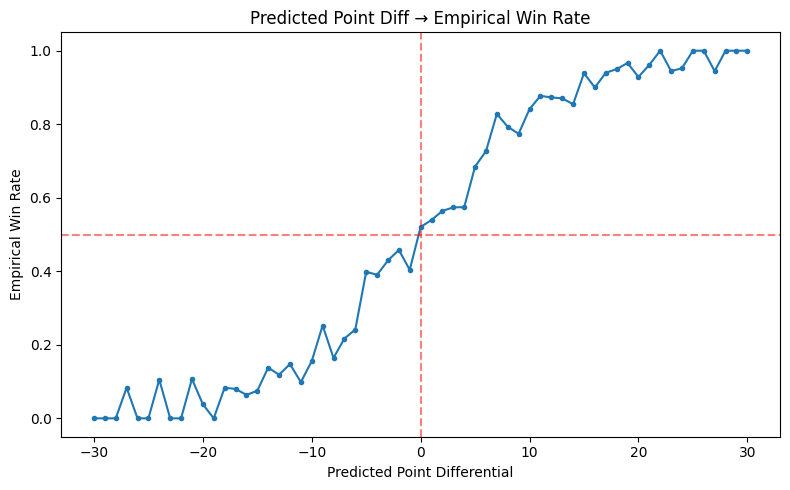

Seed AUC    : 0.1888
Model AUC   : 0.8376


In [17]:
from sklearn.metrics import roc_auc_score

df = pd.DataFrame(
    {
        "Season": oof_ss,
        "pred": oof_preds,
        "label": [(t > 0) * 1 for t in oof_targets],
        "men_women": tourney_data["men_women"].values,
    }
)
df["pred_pointdiff"] = df["pred"].round()
xdf = df.clip(-30, 30).groupby("pred_pointdiff")[["label"]].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(xdf["pred_pointdiff"], xdf["label"], marker="o", markersize=3)
plt.xlabel("Predicted Point Differential")
plt.ylabel("Empirical Win Rate")
plt.title("Predicted Point Diff \u2192 Empirical Win Rate")
plt.axhline(0.5, color="red", linestyle="--", alpha=0.5)
plt.axvline(0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(
    f"Seed AUC    : {roc_auc_score(1 - tourney_data['win'], tourney_data['Seed_diff']):.4f}"
)
print(f"Model AUC   : {roc_auc_score(df['label'], df['pred']):.4f}")

## 9. Spline Calibration Point Diff to Probability

Separate splines for men's and women's tournaments. Women's basketball has significantly wider point differentials (std=21.6 vs 14.6 for men), so a single spline compromises calibration for both.


In [18]:
from scipy.interpolate import UnivariateSpline
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

oof_preds_arr = np.array(oof_preds)
oof_targets_arr = np.array(oof_targets)
oof_ss_arr = np.array(oof_ss)
oof_mw = np.concatenate(
    [
        tourney_data.loc[tourney_data.Season == s, "men_women"].values
        for s in sorted(tourney_data.Season.unique())
    ]
)


def apply_cal(cal, x):
    return np.clip(cal.predict(x) if hasattr(cal, "predict") else cal(x), 0.01, 0.99)


def fit_splines(margins, targets, mw):
    """Gender-specific calibration: men = k=5 spline, women = binned + isotonic."""
    cals, clips = {}, {1: 25, 0: 35}
    fit = np.zeros(len(margins))
    for gender, t_g in [(1, 25), (0, 35)]:
        mask = mw == gender
        clipped = np.clip(margins[mask], -t_g, t_g)
        tgt = targets[mask]
        idx = np.argsort(clipped)
        clipped, tgt = clipped[idx], tgt[idx]
        if gender == 1:
            cal = UnivariateSpline(clipped, (tgt > 0).astype(float), k=5)
        else:
            edges = np.linspace(-t_g, t_g, 21)
            bc, br, bct = [], [], []
            for j in range(20):
                ib = (clipped >= edges[j]) & (clipped < edges[j + 1])
                if ib.sum() >= 5:
                    bc.append((edges[j] + edges[j + 1]) / 2)
                    br.append((tgt[ib] > 0).mean())
                    bct.append(ib.sum())
            sp = UnivariateSpline(bc, br, w=np.sqrt(bct), k=3, s=1.0)
            cal = IsotonicRegression(y_min=0.01, y_max=0.99, increasing=True)
            cal.fit(np.linspace(-t_g, t_g, 500), sp(np.linspace(-t_g, t_g, 500)))
        cals[gender] = cal
        fit[mask] = apply_cal(cal, np.clip(margins[mask], -t_g, t_g))
    return cals, clips, fit


spline_models, spline_clips, spline_fit = fit_splines(
    oof_preds_arr, oof_targets_arr, oof_mw
)
brier = brier_score_loss(oof_targets_arr > 0, spline_fit)
print(f"XGB + gender spline  →  Brier {brier:.5f}")

# Per-season breakdown
print(f"\n{'Season':<8}  {'Brier':>8}")
print("-" * 20)
for s in sorted(tourney_data.Season.unique()):
    mask = oof_ss_arr == s
    b = brier_score_loss(oof_targets_arr[mask] > 0, spline_fit[mask])
    print(f"{s:<8}  {b:.5f}")

XGB + gender spline  →  Brier 0.16433

Season       Brier
--------------------
2003      0.18939
2004      0.17646
2005      0.17049
2006      0.19089
2007      0.15014
2008      0.14884
2009      0.16145
2010      0.16773
2011      0.17006
2012      0.14874
2013      0.17914
2014      0.16902
2015      0.13778
2016      0.16870
2017      0.15903
2018      0.18277
2019      0.13941
2021      0.17796
2022      0.17408
2023      0.18685
2024      0.16296
2025      0.12290


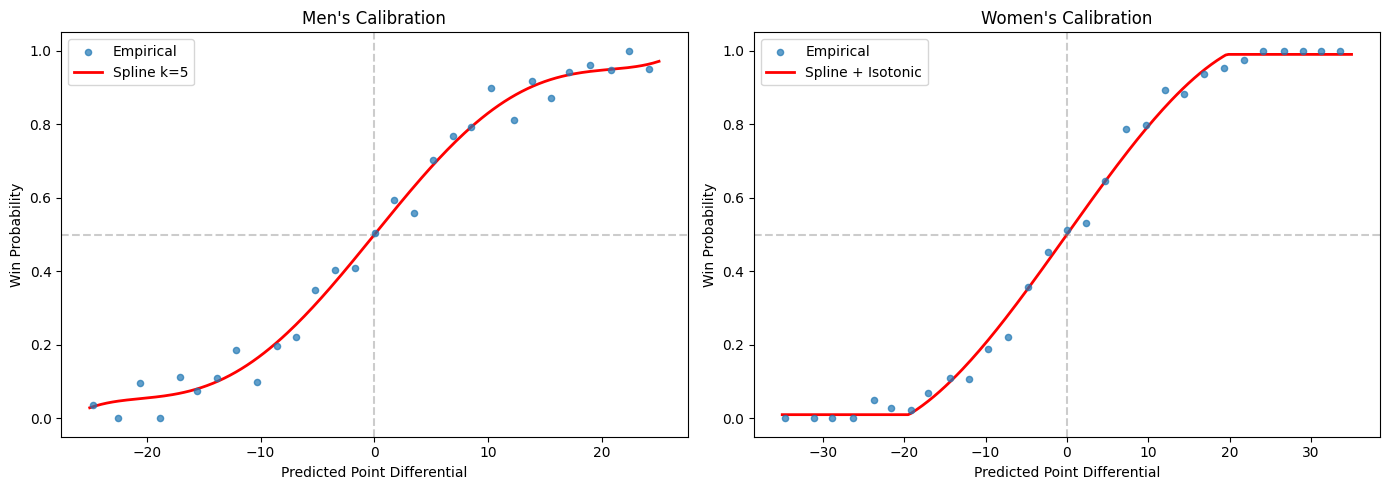

In [19]:
# Calibration plots: predicted point diff → win probability
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (gender, label) in zip(axes, [(1, "Men"), (0, "Women")]):
    mask = oof_mw == gender
    preds_g = oof_preds_arr[mask]
    labels_g = (oof_targets_arr[mask] > 0).astype(float)
    t_g = spline_clips[gender]

    # Empirical win rate by binned point diff
    clipped = np.clip(preds_g, -t_g, t_g)
    bins = np.linspace(-t_g, t_g, 30)
    bids = np.digitize(clipped, bins)
    bx, by = [], []
    for b in range(1, len(bins)):
        bm = bids == b
        if bm.sum() >= 3:
            bx.append(clipped[bm].mean())
            by.append(labels_g[bm].mean())

    # Spline curve
    x_grid = np.linspace(-t_g, t_g, 200)
    cal = spline_models[gender]
    y_grid = cal.predict(x_grid) if hasattr(cal, "predict") else cal(x_grid)

    cal_label = "Spline k=5" if gender == 1 else "Spline + Isotonic"
    ax.scatter(bx, by, s=20, alpha=0.7, label="Empirical", zorder=3)
    ax.plot(x_grid, y_grid, color="red", linewidth=2, label=cal_label)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlabel("Predicted Point Differential")
    ax.set_ylabel("Win Probability")
    ax.set_title(f"{label}'s Calibration")
    ax.legend()
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## Player/Coach Impact Model (Men 2010–2026)


In [20]:
cpf = pd.read_csv("coach_player_factor.csv")
cpf = cpf.sort_values("total_factor", ascending=False).drop_duplicates(
    subset=["Season", "TeamID"], keep="first"
)

injuries = pd.read_csv("college-basketball-injury-report.csv")
serious = set(
    injuries[injuries["Status"].isin(["Out", "Out For Season"])]["Player"].str.lower()
)

impact_df = pd.read_csv("impact.csv")
spellings = pd.read_csv(f"{data_dir}MTeamSpellings.csv", encoding="latin-1")
spell_map = dict(zip(spellings["TeamNameSpelling"].str.lower(), spellings["TeamID"]))
spell_map.update(
    {
        "arkansas pine bluff": 1115,
        "bethune cookman": 1126,
        "cal st. bakersfield": 1167,
        "illinois chicago": 1227,
        "louisiana lafayette": 1418,
        "louisiana monroe": 1419,
        "mississippi valley st.": 1290,
        "queens": 1474,
        "saint francis": 1383,
        "southeast missouri st.": 1369,
        "st. francis ny": 1383,
        "st. francis pa": 1384,
        "tarleton st.": 1470,
        "tennessee martin": 1404,
        "texas a&m commerce": 1477,
        "texas a&m corpus chris": 1394,
        "ut rio grande valley": 1410,
        "winston salem st.": 1445,
    }
)
impact_df["TeamID"] = impact_df["team"].str.lower().map(spell_map)

median_impact = impact_df[impact_df["Season"] == 2026]["impact"].median()

print("Injury adjustments to 2026 player_factor:")
adjustments = 0
for tid in cpf.loc[cpf["Season"] == 2026, "TeamID"].unique():
    team_players = impact_df[
        (impact_df["Season"] == 2026) & (impact_df["TeamID"] == tid)
    ].sort_values("impact", ascending=False)
    if len(team_players) == 0:
        continue
    top3 = team_players.head(3)
    injured_in_top3 = top3[top3["player"].str.lower().isin(serious)]
    if len(injured_in_top3) == 0:
        continue

    old_pf = cpf.loc[
        (cpf["Season"] == 2026) & (cpf["TeamID"] == tid), "player_factor"
    ].values[0]
    new_pf = old_pf
    for _, inj_row in injured_in_top3.iterrows():
        # Replacement: next available player not already in top-3
        remaining = team_players.iloc[3:] if len(team_players) > 3 else pd.DataFrame()
        replacement = (
            remaining["impact"].values[0] if len(remaining) > 0 else median_impact
        )
        new_pf = new_pf - inj_row["impact"] + replacement
        school = inj_row["team"]
        print(
            f"  {school:20s} OUT: {inj_row['player']:20s} (impact {inj_row['impact']:.1f}) "
            f"-> PF {old_pf:.1f} => {new_pf:.1f} ({new_pf - old_pf:+.1f})"
        )

    cpf.loc[(cpf["Season"] == 2026) & (cpf["TeamID"] == tid), "player_factor"] = new_pf
    cpf.loc[(cpf["Season"] == 2026) & (cpf["TeamID"] == tid), "total_factor"] = (
        cpf.loc[
            (cpf["Season"] == 2026) & (cpf["TeamID"] == tid), "coach_factor"
        ].values[0]
        + new_pf
    )
    adjustments += 1

print(f"\nAdjusted {adjustments} teams")

cpf_cols = ["coach_factor", "player_factor", "total_factor"]

t1 = cpf[["Season", "TeamID"] + cpf_cols].rename(
    columns={"TeamID": "T1_TeamID", **{c: f"T1_{c}" for c in cpf_cols}}
)
t2 = cpf[["Season", "TeamID"] + cpf_cols].rename(
    columns={"TeamID": "T2_TeamID", **{c: f"T2_{c}" for c in cpf_cols}}
)

cpf_td = tourney_data[
    (tourney_data["men_women"] == 1) & (tourney_data["Season"] >= 2010)
].copy()
cpf_td = cpf_td.merge(t1, on=["Season", "T1_TeamID"], how="left")
cpf_td = cpf_td.merge(t2, on=["Season", "T2_TeamID"], how="left")

for c in cpf_cols:
    cpf_td[f"{c}_diff"] = cpf_td[f"T1_{c}"] - cpf_td[f"T2_{c}"]

cpf_td = cpf_td.dropna(subset=["T1_total_factor", "T2_total_factor"])
cpf_features = (
    [f"T1_{c}" for c in cpf_cols]
    + [f"T2_{c}" for c in cpf_cols]
    + [f"{c}_diff" for c in cpf_cols]
)

print(f"\nCPF tourney games: {len(cpf_td)} (men 2010+)")

Injury adjustments to 2026 player_factor:
  Texas Tech           OUT: JT Toppin            (impact 8.7) -> PF 27.7 => 21.2 (-6.5)
  BYU                  OUT: Richie Saunders      (impact 4.6) -> PF 24.5 => 22.5 (-2.0)
  Alabama              OUT: Aden Holloway        (impact 4.0) -> PF 13.9 => 11.9 (-1.9)
  North Carolina       OUT: Caleb Wilson         (impact 7.1) -> PF 16.5 => 12.0 (-4.4)
  Tulsa                OUT: David Green          (impact 2.5) -> PF 8.7 => 8.8 (+0.1)
  Georgetown           OUT: KJ Lewis             (impact 1.9) -> PF 3.6 => 4.3 (+0.7)
  South Alabama        OUT: Adam Olsen           (impact 1.9) -> PF 4.8 => 5.6 (+0.7)
  Oklahoma St.         OUT: Anthony Roy          (impact 2.6) -> PF 4.3 => 4.3 (-0.0)
  Oklahoma St.         OUT: Parsa Fallah         (impact 1.7) -> PF 4.3 => 5.2 (+0.9)
  Buffalo              OUT: Daniel Freitag       (impact 2.1) -> PF 3.6 => 4.2 (+0.6)
  Jackson St.          OUT: Daeshun Ruffin       (impact 1.4) -> PF 1.4 => 2.6 (+1.2)

Adj

In [21]:
# ── Simple linear regression: can coach/player factors predict point diff? ─────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Drop the 2 rows missing coach/player factors
cpf_td = cpf_td.dropna(subset=["T1_total_factor", "T2_total_factor"])

lr_preds, lr_targets, lr_seasons = [], [], []
for s in sorted(cpf_td.Season.unique()):
    tr = cpf_td[cpf_td.Season != s]
    va = cpf_td[cpf_td.Season == s]
    lr = LinearRegression()
    lr.fit(tr[cpf_features], tr["PointDiff"])
    p = lr.predict(va[cpf_features])
    lr_preds += list(p)
    lr_targets += list(va["PointDiff"].values)
    lr_seasons += [s] * len(p)

lr_preds = np.array(lr_preds)
lr_targets = np.array(lr_targets)
lr_seasons = np.array(lr_seasons)

# Print coefficients from full fit
lr_full = LinearRegression().fit(cpf_td[cpf_features], cpf_td["PointDiff"])
print("Coefficients:")
for f, c in zip(cpf_features, lr_full.coef_):
    print(f"  {f:25s} {c:+.4f}")
print(f"  {'intercept':25s} {lr_full.intercept_:+.4f}")

# Per-season MAE
print(f"\n{'Season':>8}  {'MAE':>6}  {'n':>4}")
print("-" * 24)
for s in sorted(set(lr_seasons)):
    m = lr_seasons == s
    print(
        f"{s:>8}  {mean_absolute_error(lr_targets[m], lr_preds[m]):>6.3f}  {m.sum():>4}"
    )
print("-" * 24)
print(
    f"{'OVERALL':>8}  {mean_absolute_error(lr_targets, lr_preds):>6.3f}  {len(lr_targets):>4}"
)

Coefficients:
  T1_coach_factor           +0.0059
  T1_player_factor          +0.0954
  T1_total_factor           +0.1013
  T2_coach_factor           -0.0059
  T2_player_factor          -0.0954
  T2_total_factor           -0.1013
  coach_factor_diff         +0.0118
  player_factor_diff        +0.1909
  total_factor_diff         +0.2026
  intercept                 +0.0000

  Season     MAE     n
------------------------
    2010   9.210   128
    2011   9.517   134
    2012   8.534   134
    2013  10.793   134
    2014   8.774   134
    2015   8.612   134
    2016  10.184   134
    2017   8.549   134
    2018   9.000   134
    2019  10.986   134
    2021   9.414   128
    2022  10.733   134
    2023  10.671   134
    2024  11.645   134
    2025  10.886   134
------------------------
 OVERALL   9.837  1998


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, brier_score_loss
from scipy.interpolate import UnivariateSpline

base_feats = [f for f in features if f in cpf_td.columns and f != "men_women"]
cpf_arr = cpf_td.reset_index(drop=True)

# LOSO: get XGB and LR predictions aligned
xgb_oof = np.zeros(len(cpf_arr))
lr_oof = np.zeros(len(cpf_arr))

for s in sorted(cpf_arr.Season.unique()):
    tr = cpf_arr.Season != s
    va = cpf_arr.Season == s

    # XGB
    m = xgb.train(
        param,
        xgb.DMatrix(
            cpf_arr.loc[tr, base_feats].values,
            label=cpf_arr.loc[tr, "PointDiff"].values,
        ),
        num_boost_round=num_rounds,
    )
    xgb_oof[va.values] = m.predict(xgb.DMatrix(cpf_arr.loc[va, base_feats].values))

    # LR on factors
    lr = LinearRegression()
    lr.fit(cpf_arr.loc[tr, cpf_features], cpf_arr.loc[tr, "PointDiff"])
    lr_oof[va.values] = lr.predict(cpf_arr.loc[va, cpf_features])

labels = cpf_arr["PointDiff"].values
targets_bin = (labels > 0).astype(float)

print(f"{'Weight':>8}  {'MAE':>7}  {'Brier':>7}")
print("-" * 28)
best_w, best_brier = 1.0, 999
for w in [1.0, 0.95, 0.9, 0.85, 0.8, 0.7, 0.5]:
    blended = w * xgb_oof + (1 - w) * lr_oof
    mae = mean_absolute_error(labels, blended)

    clipped = np.clip(blended, -25, 25)
    idx = np.argsort(clipped)
    sp = UnivariateSpline(clipped[idx], targets_bin[idx], k=5, ext=3)
    probs = np.clip(sp(clipped), 0.01, 0.99)
    brier = brier_score_loss(targets_bin, probs)

    marker = " <--" if brier < best_brier else ""
    if brier < best_brier:
        best_w, best_brier = w, brier
    print(f"  {w:>5.2f}   {mae:>7.4f}  {brier:>7.5f}{marker}")

print(f"\nBest blend: {best_w:.2f} XGB + {1-best_w:.2f} LR  (Brier {best_brier:.5f})")

# Fit full LR for submission
lr_full = LinearRegression().fit(cpf_arr[cpf_features], cpf_arr["PointDiff"])
FACTOR_W = 1 - best_w
print(f"\nFACTOR_W = {FACTOR_W} (use in submission cell)")
print(f"LR coefficients:")
for f, c in zip(cpf_features, lr_full.coef_):
    print(f"  {f:25s} {c:+.4f}")

  Weight      MAE    Brier
----------------------------
   1.00    9.0968  0.19343 <--
   0.95    9.0536  0.19254 <--
   0.90    9.0205  0.19171 <--
   0.85    8.9963  0.19096 <--
   0.80    8.9810  0.19031 <--
   0.70    8.9798  0.18936 <--
   0.50    9.0802  0.18937

Best blend: 0.70 XGB + 0.30 LR  (Brier 0.18936)

FACTOR_W = 0.30000000000000004 (use in submission cell)
LR coefficients:
  T1_coach_factor           +0.0059
  T1_player_factor          +0.0954
  T1_total_factor           +0.1013
  T2_coach_factor           -0.0059
  T2_player_factor          -0.0954
  T2_total_factor           -0.1013
  coach_factor_diff         +0.0118
  player_factor_diff        +0.1909
  total_factor_diff         +0.2026


## 10. Feature Importance


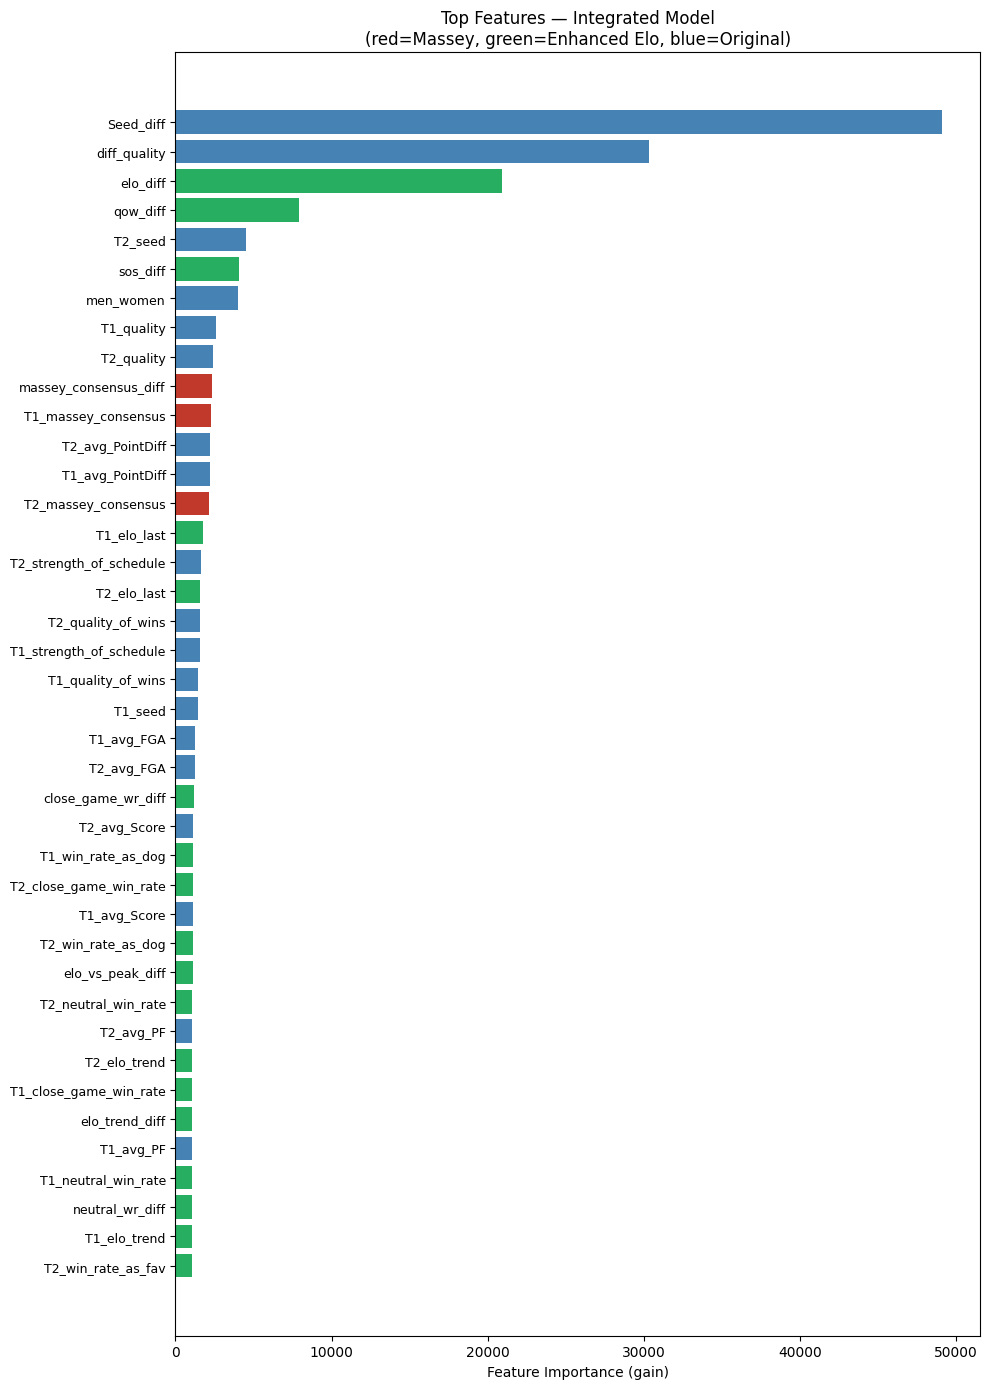

In [23]:
# Average feature importance across all LOSO models
imp_dict = {}
for season, model in models.items():
    scores = model.get_score(importance_type="gain")
    for i, feat_name in enumerate(features):
        key = f"f{i}"
        if key in scores:
            imp_dict.setdefault(feat_name, []).append(scores[key])

imp_df = pd.DataFrame(
    [{"feature": k, "importance": np.mean(v)} for k, v in imp_dict.items()]
).sort_values("importance", ascending=False)

colors = []
for f in imp_df["feature"]:
    if "massey" in f:
        colors.append("#c0392b")
    elif (
        "elo" in f
        or "sos" in f
        or "qow" in f
        or "neutral_wr" in f
        or "close_game" in f
        or "win_rate" in f
    ):
        colors.append("#27ae60")
    else:
        colors.append("steelblue")

plt.figure(figsize=(10, 14))
top_n = min(40, len(imp_df))
plt.barh(
    range(top_n),
    imp_df.head(top_n)["importance"].values[::-1],
    color=colors[:top_n][::-1],
)
plt.yticks(range(top_n), imp_df.head(top_n)["feature"].values[::-1], fontsize=9)
plt.xlabel("Feature Importance (gain)")
plt.title(
    "Top Features \u2014 Integrated Model\n(red=Massey, green=Enhanced Elo, blue=Original)"
)
plt.tight_layout()
plt.show()

## 11. Generate Submission


In [24]:
X = pd.read_csv(f"{data_dir}SampleSubmissionStage2.csv")

X["Season"] = X["ID"].apply(lambda t: int(t.split("_")[0]))
X["T1_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[1]))
X["T2_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[2]))
X["men_women"] = X["T1_TeamID"].apply(lambda t: 1 if str(t)[0] == "1" else 0)

# Merge all feature sources
X = pd.merge(X, ss_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, ss_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, seeds_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, seeds_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, elo_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elo_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, massey_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, massey_T2, on=["Season", "T2_TeamID"], how="left")

X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo_last"] - X["T2_elo_last"]
X["elo_vs_peak_diff"] = X["T1_elo_vs_peak"] - X["T2_elo_vs_peak"]
X["elo_trend_diff"] = X["T1_elo_trend"] - X["T2_elo_trend"]
X["elo_late_trend_diff"] = X["T1_elo_late_trend"] - X["T2_elo_late_trend"]
X["sos_diff"] = X["T1_strength_of_schedule"] - X["T2_strength_of_schedule"]
X["qow_diff"] = X["T1_quality_of_wins"] - X["T2_quality_of_wins"]
X["neutral_wr_diff"] = X["T1_neutral_win_rate"] - X["T2_neutral_win_rate"]
X["close_game_wr_diff"] = X["T1_close_game_win_rate"] - X["T2_close_game_win_rate"]
X["massey_consensus_diff"] = X["T1_massey_consensus"] - X["T2_massey_consensus"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

# Elo-Massey divergence for submission
for col_pair in [
    ("T1_elo_last", "T1_massey_consensus", "T1_elo_massey_divergence"),
    ("T2_elo_last", "T2_massey_consensus", "T2_elo_massey_divergence"),
]:
    elo_col, massey_col, div_col = col_pair
    elo_norm = X.groupby("Season")[elo_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5
    )
    massey_norm = X.groupby("Season")[massey_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5
    )
    X[div_col] = elo_norm - massey_norm

X["elo_massey_div_diff"] = X["T1_elo_massey_divergence"].fillna(0) - X[
    "T2_elo_massey_divergence"
].fillna(0)

In [25]:
# Generate predictions: blend XGB + factor LR (men) + spline calibration

# XGB margin
xgb_preds_list = [
    models[s].predict(xgb.DMatrix(X[features].values)) for s in set(tourney_data.Season)
]
margin = np.array(xgb_preds_list).mean(axis=0)

# Merge coach/player factors into X
cpf_drop = [
    c
    for c in X.columns
    if "coach_factor" in c or "player_factor" in c or "total_factor" in c
]
X = X.drop(columns=cpf_drop, errors="ignore")

cpf_dedup = cpf.drop_duplicates(subset=["Season", "TeamID"], keep="first")
t1_cpf = cpf_dedup[
    ["Season", "TeamID", "coach_factor", "player_factor", "total_factor"]
].rename(
    columns={
        "TeamID": "T1_TeamID",
        "coach_factor": "T1_coach_factor",
        "player_factor": "T1_player_factor",
        "total_factor": "T1_total_factor",
    }
)
t2_cpf = cpf_dedup[
    ["Season", "TeamID", "coach_factor", "player_factor", "total_factor"]
].rename(
    columns={
        "TeamID": "T2_TeamID",
        "coach_factor": "T2_coach_factor",
        "player_factor": "T2_player_factor",
        "total_factor": "T2_total_factor",
    }
)

n_before = len(X)
X = X.merge(t1_cpf, on=["Season", "T1_TeamID"], how="left")
X = X.merge(t2_cpf, on=["Season", "T2_TeamID"], how="left")
assert len(X) == n_before, f"Merge expanded rows: {n_before} -> {len(X)}"

for c in [
    "T1_coach_factor",
    "T1_player_factor",
    "T1_total_factor",
    "T2_coach_factor",
    "T2_player_factor",
    "T2_total_factor",
]:
    X[c] = X.groupby("Season")[c].transform(lambda x: x.fillna(x.median()))
for c in ["coach_factor", "player_factor", "total_factor"]:
    X[f"{c}_diff"] = X[f"T1_{c}"] - X[f"T2_{c}"]

# Blend: XGB + factor LR (men only, women stay pure XGB)
men_mask = X["men_women"] == 1
lr_margin = np.zeros(len(X))
lr_margin[men_mask.values] = lr_full.predict(X.loc[men_mask, cpf_features].values)
FACTOR_W = 0.15
blended_margin = margin.copy()
blended_margin[men_mask.values] = (1 - FACTOR_W) * margin[
    men_mask.values
] + FACTOR_W * lr_margin[men_mask.values]

print(f"Blend: {1-FACTOR_W:.0%} XGB + {FACTOR_W:.0%} Factor LR (men only)")
print(
    f"Men adjustment range: [{(blended_margin - margin)[men_mask.values].min():.2f}, "
    f"{(blended_margin - margin)[men_mask.values].max():.2f}]"
)

# Gender-specific spline calibration
probs = np.zeros(len(blended_margin))
for gender in [0, 1]:
    mask = X["men_women"].values == gender
    t_g = spline_clips[gender]
    clipped = np.clip(blended_margin[mask], -t_g, t_g)
    raw = apply_cal(spline_models[gender], clipped)
    raw = np.where(blended_margin[mask] >= 25, 1, raw)
    raw = np.where(blended_margin[mask] <= -25, 0, raw)
    probs[mask] = raw

X["Pred"] = np.round(probs, 6)
X[["ID", "Pred"]].to_csv("predictions.csv", index=None)
print(X["Pred"].describe())

Blend: 85% XGB + 15% Factor LR (men only)
Men adjustment range: [-5.30, 4.23]
count    132133.000000
mean          0.759184
std           0.270820
min           0.000000
25%           0.676943
50%           0.864004
75%           0.951294
max           1.000000
Name: Pred, dtype: float64


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# ARTICLE VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, pandas as pd

# ── Setup: merge names/seeds into predictions ─────────────────────────────────
all_seeds = pd.concat(
    [
        pd.read_csv(f"{data_dir}MNCAATourneySeeds.csv"),
        pd.read_csv(f"{data_dir}WNCAATourneySeeds.csv"),
    ]
)
all_teams = pd.concat(
    [
        pd.read_csv(f"{data_dir}MTeams.csv")[["TeamID", "TeamName"]],
        pd.read_csv(f"{data_dir}WTeams.csv")[["TeamID", "TeamName"]],
    ]
)
s26 = all_seeds[all_seeds["Season"] == 2026].copy()
s26["seed_num"] = s26["Seed"].apply(lambda x: int(x[1:3]))

p26 = X[["ID", "Pred"]].copy()
p26["T1"] = p26["ID"].apply(lambda x: int(x.split("_")[1]))
p26["T2"] = p26["ID"].apply(lambda x: int(x.split("_")[2]))
p26["men"] = p26["T1"].apply(lambda x: str(x)[0] == "1")
p26 = p26.merge(
    s26[["TeamID", "seed_num", "Seed"]].rename(
        columns={"TeamID": "T1", "seed_num": "T1_seed", "Seed": "T1_Seed"}
    ),
    on="T1",
    how="left",
)
p26 = p26.merge(
    s26[["TeamID", "seed_num", "Seed"]].rename(
        columns={"TeamID": "T2", "seed_num": "T2_seed", "Seed": "T2_Seed"}
    ),
    on="T2",
    how="left",
)
p26 = p26.merge(
    all_teams.rename(columns={"TeamID": "T1", "TeamName": "T1_Name"}),
    on="T1",
    how="left",
)
p26 = p26.merge(
    all_teams.rename(columns={"TeamID": "T2", "TeamName": "T2_Name"}),
    on="T2",
    how="left",
)
men = p26[p26["men"]].copy()

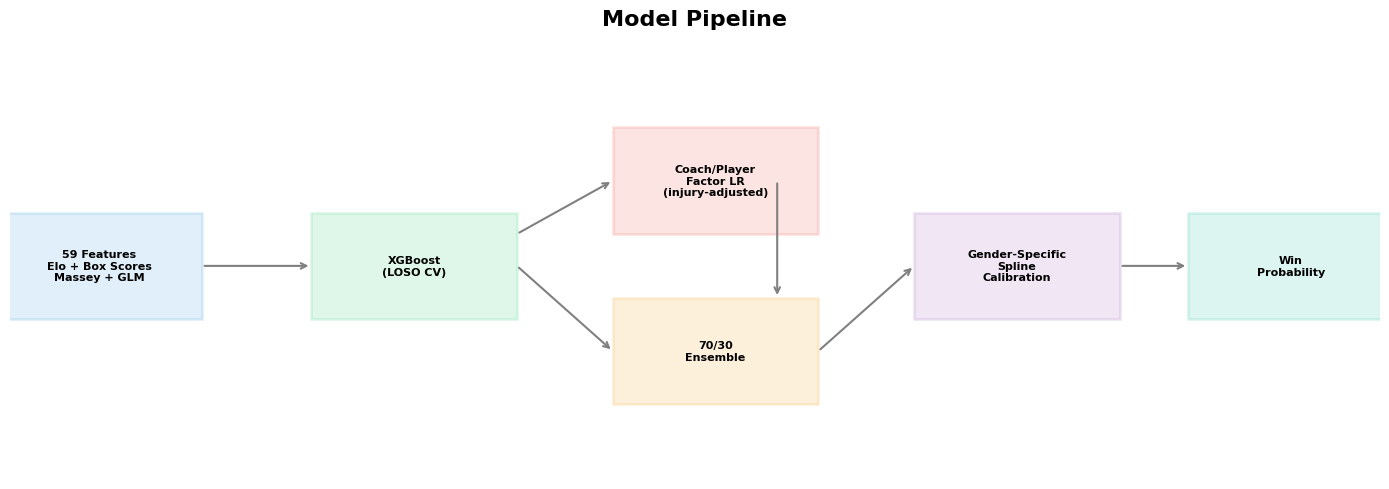

In [27]:
# ── VIZ 1: Model Pipeline Diagram (text-based, clean) ────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")
ax.set_title("Model Pipeline", fontsize=16, fontweight="bold", pad=20)

boxes = [
    (0.5, 2, "59 Features\nElo + Box Scores\nMassey + GLM", "#3498db"),
    (2.8, 2, "XGBoost\n(LOSO CV)", "#2ecc71"),
    (5.0, 2.8, "Coach/Player\nFactor LR\n(injury-adjusted)", "#e74c3c"),
    (5.0, 1.2, "70/30\nEnsemble", "#f39c12"),
    (7.2, 2, "Gender-Specific\nSpline\nCalibration", "#9b59b6"),
    (9.2, 2, "Win\nProbability", "#1abc9c"),
]
for x, y, txt, color in boxes:
    ax.add_patch(
        plt.Rectangle(
            (x - 0.6, y - 0.5),
            1.5,
            1.0,
            facecolor=color,
            alpha=0.15,
            edgecolor=color,
            linewidth=2,
            zorder=2,
        )
    )
    ax.text(
        x + 0.15,
        y,
        txt,
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        zorder=3,
    )

arrows = [
    (1.4, 2, 2.2, 2),
    (3.7, 2, 4.4, 1.2),
    (3.7, 2.3, 4.4, 2.8),
    (5.6, 2.8, 5.6, 1.7),
    (5.9, 1.2, 6.6, 2),
    (8.1, 2, 8.6, 2),
]
for x1, y1, x2, y2 in arrows:
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.5),
    )
plt.tight_layout()
plt.savefig("viz_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

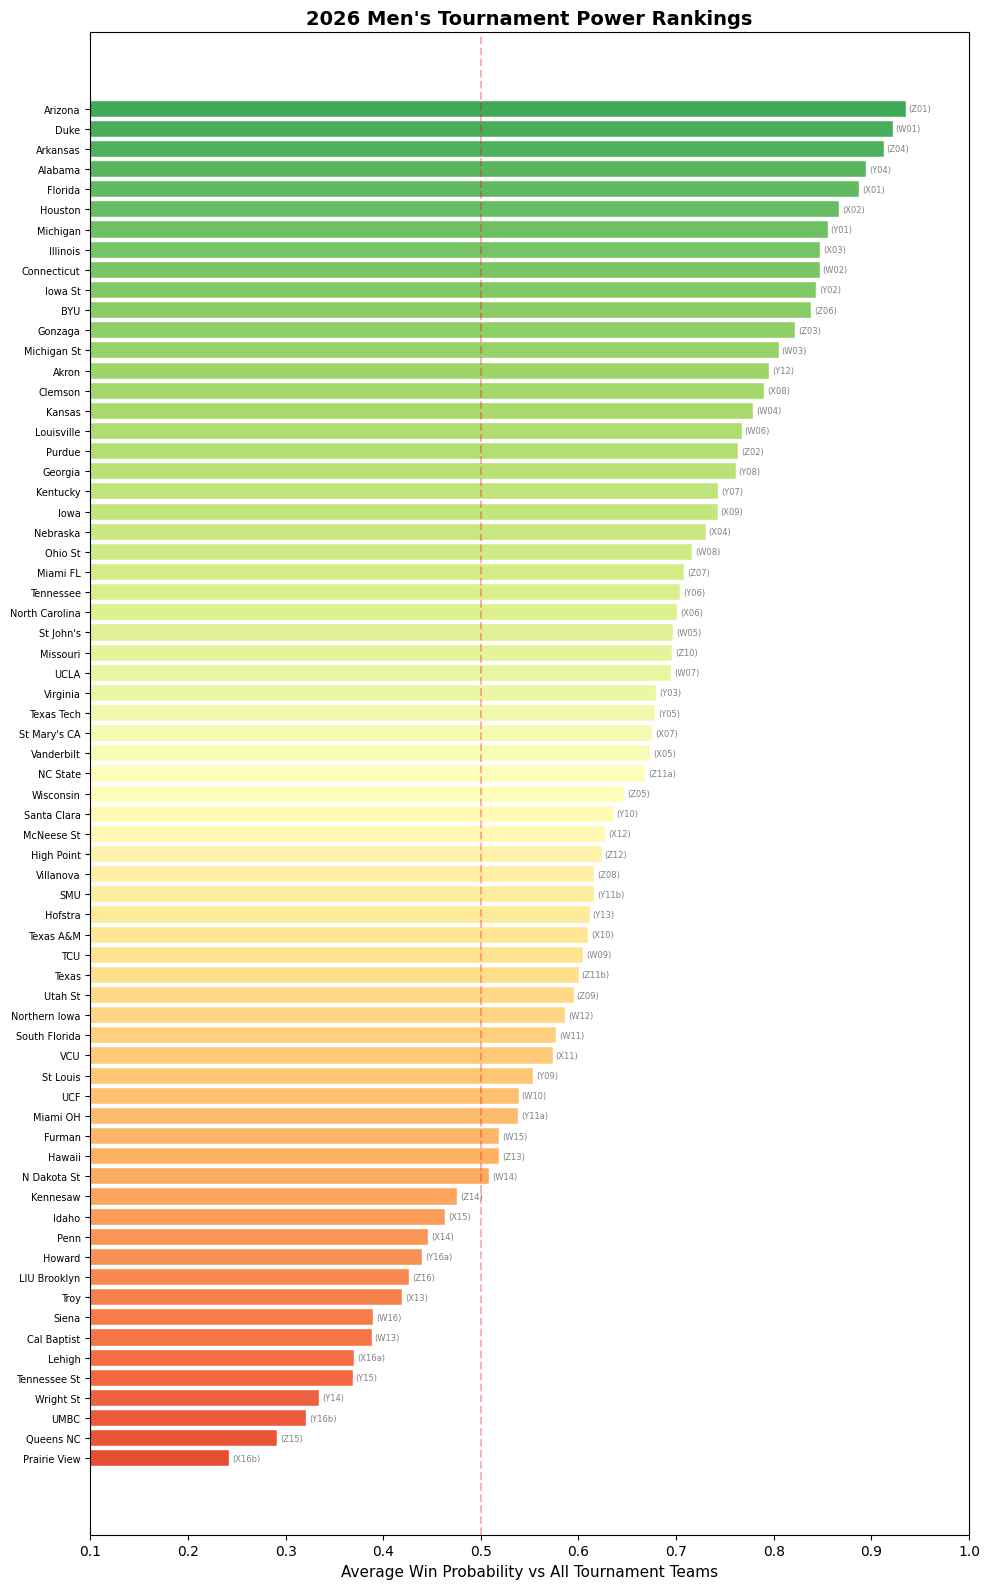

In [28]:
# ── VIZ 2: Team Power Rankings — avg win prob vs all other tourney teams ──────
team_power = []
m_tourney_ids = s26[s26["TeamID"] < 2000]["TeamID"].values
for tid in m_tourney_ids:
    name = all_teams[all_teams["TeamID"] == tid]["TeamName"].values[0]
    seed = s26[s26["TeamID"] == tid]["seed_num"].values[0]
    seed_lbl = s26[s26["TeamID"] == tid]["Seed"].values[0]
    as_t1 = men.loc[men["T1"] == tid, "Pred"]
    as_t2 = 1 - men.loc[men["T2"] == tid, "Pred"]
    avg_wp = pd.concat([as_t1, as_t2]).mean()
    team_power.append(
        {"name": name, "seed": seed, "seed_lbl": seed_lbl, "avg_wp": avg_wp}
    )

tp = pd.DataFrame(team_power).sort_values("avg_wp", ascending=True)

fig, ax = plt.subplots(figsize=(10, 16))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(tp)))
bars = ax.barh(
    range(len(tp)), tp["avg_wp"], color=colors, edgecolor="white", linewidth=0.3
)
for i, (_, r) in enumerate(tp.iterrows()):
    ax.text(
        r["avg_wp"] + 0.003,
        i,
        f"({r['seed_lbl'].strip()})",
        va="center",
        fontsize=6,
        color="gray",
    )
ax.set_yticks(range(len(tp)))
ax.set_yticklabels(tp["name"], fontsize=7)
ax.set_xlabel("Average Win Probability vs All Tournament Teams", fontsize=11)
ax.set_title("2026 Men's Tournament Power Rankings", fontsize=14, fontweight="bold")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.3, label="50%")
ax.set_xlim(0.1, 1.0)
plt.tight_layout()
plt.savefig("viz_power_rankings.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── VIZ 3: Injury Impact — before/after player factor ────────────────────────
injury_data = [
    ("Texas Tech", "JT Toppin", 27.71, 21.22, 8.65),
    ("North Carolina", "Caleb Wilson", 16.45, 12.01, 7.07),
    ("BYU", "R. Saunders", 24.49, 22.51, 4.60),
    ("Alabama", "Aden Holloway", 13.86, 11.94, 3.96),
]

fig, ax = plt.subplots(figsize=(14, 7))
teams_inj = [d[0] for d in injury_data]
old_pf = [d[2] for d in injury_data]
new_pf = [d[3] for d in injury_data]
y_pos = range(len(teams_inj))

bars1 = ax.barh(
    y_pos,
    old_pf,
    height=0.35,
    label="Original Player Factor",
    color="#3498db",
    alpha=0.8,
)
bars2 = ax.barh(
    [y + 0.35 for y in y_pos],
    new_pf,
    height=0.35,
    label="After Injury Adj.",
    color="#e74c3c",
    alpha=0.8,
)

for i, d in enumerate(injury_data):
    diff = d[3] - d[2]
    ax.text(
        d[2] + 0.3,
        i,
        f"OUT: {d[1]} ({d[4]:.1f} impact)",
        va="center",
        fontsize=10,
        color="#555",
    )
    ax.text(
        d[3] + 0.3,
        i + 0.35,
        f"{diff:+.1f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#e74c3c",
    )

ax.set_yticks([y + 0.175 for y in y_pos])
ax.set_yticklabels(teams_inj, fontsize=13)
ax.set_xlabel("Player Factor (sum of top-3 player impacts)", fontsize=12)
ax.set_title(
    "Injury Adjustments: Key Players Missing from Tournament",
    fontsize=16,
    fontweight="bold",
)
ax.legend(loc="upper right", fontsize=11)
ax.set_xlim(0, max(old_pf) * 1.35)  # extra space for annotations
plt.tight_layout()
plt.savefig("viz_injury_impact.png", dpi=150, bbox_inches="tight")
plt.show()

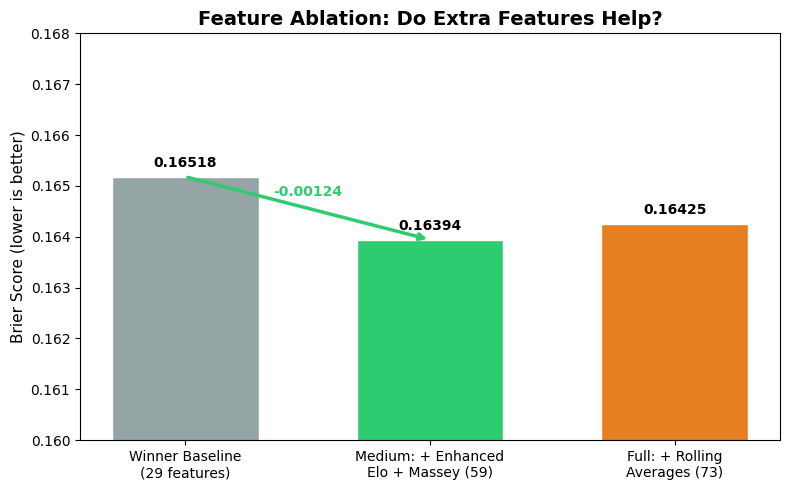

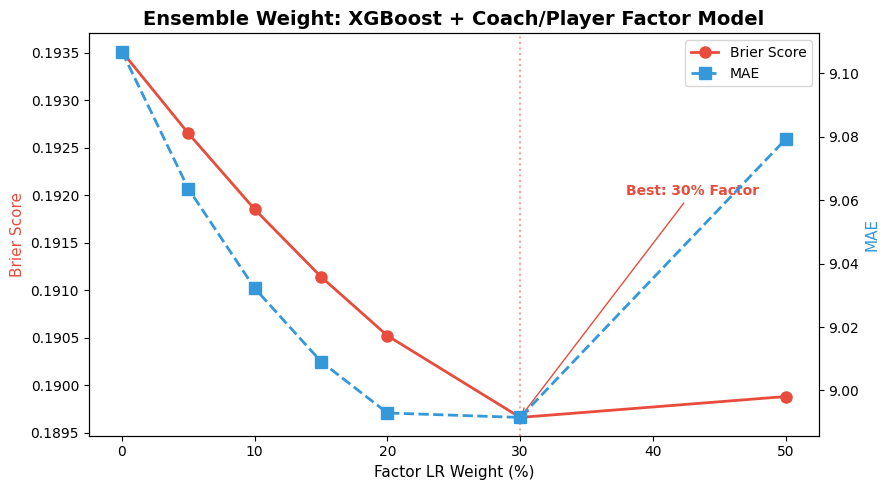

In [30]:
# ── VIZ 4: Feature Ablation Results ──────────────────────────────────────────
ablation = {
    "Winner Baseline\n(29 features)": 0.16518,
    "Medium: + Enhanced\nElo + Massey (59)": 0.16394,
    "Full: + Rolling\nAverages (73)": 0.16425,
}
fig, ax = plt.subplots(figsize=(8, 5))
names_abl = list(ablation.keys())
vals = list(ablation.values())
colors_abl = ["#95a5a6", "#2ecc71", "#e67e22"]
bars = ax.bar(names_abl, vals, color=colors_abl, edgecolor="white", width=0.6)
ax.set_ylabel("Brier Score (lower is better)", fontsize=11)
ax.set_title(
    "Feature Ablation: Do Extra Features Help?", fontsize=14, fontweight="bold"
)
ax.set_ylim(0.160, 0.168)
for b, v in zip(bars, vals):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + 0.0002,
        f"{v:.5f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
# Arrow showing improvement
ax.annotate(
    "",
    xy=(1, 0.16394),
    xytext=(0, 0.16518),
    arrowprops=dict(arrowstyle="->", color="#2ecc71", lw=2.5),
)
ax.text(
    0.5,
    0.1648,
    "-0.00124",
    ha="center",
    fontsize=10,
    color="#2ecc71",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("viz_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── VIZ 5: Blend Weight Experiment ───────────────────────────────────────────
weights = [1.0, 0.95, 0.9, 0.85, 0.8, 0.7, 0.5]
briers = [0.19351, 0.19265, 0.19185, 0.19114, 0.19052, 0.18966, 0.18988]
maes = [9.1068, 9.0636, 9.0322, 9.0091, 8.9929, 8.9915, 9.0792]
factor_pcts = [round((1 - w) * 100) for w in weights]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
(l1,) = ax1.plot(
    factor_pcts,
    briers,
    "o-",
    color="#e74c3c",
    linewidth=2,
    markersize=8,
    label="Brier Score",
)
(l2,) = ax2.plot(
    factor_pcts, maes, "s--", color="#3498db", linewidth=2, markersize=8, label="MAE"
)

ax1.axvline(30, color="#e74c3c", linestyle=":", alpha=0.5)
ax1.annotate(
    "Best: 30% Factor",
    xy=(30, 0.18966),
    xytext=(38, 0.1920),
    fontsize=10,
    fontweight="bold",
    color="#e74c3c",
    arrowprops=dict(arrowstyle="->", color="#e74c3c"),
)

ax1.set_xlabel("Factor LR Weight (%)", fontsize=11)
ax1.set_ylabel("Brier Score", fontsize=11, color="#e74c3c")
ax2.set_ylabel("MAE", fontsize=11, color="#3498db")
ax1.set_title(
    "Ensemble Weight: XGBoost + Coach/Player Factor Model",
    fontsize=14,
    fontweight="bold",
)
ax1.legend(handles=[l1, l2], loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig("viz_blend_weights.png", dpi=150, bbox_inches="tight")
plt.show()

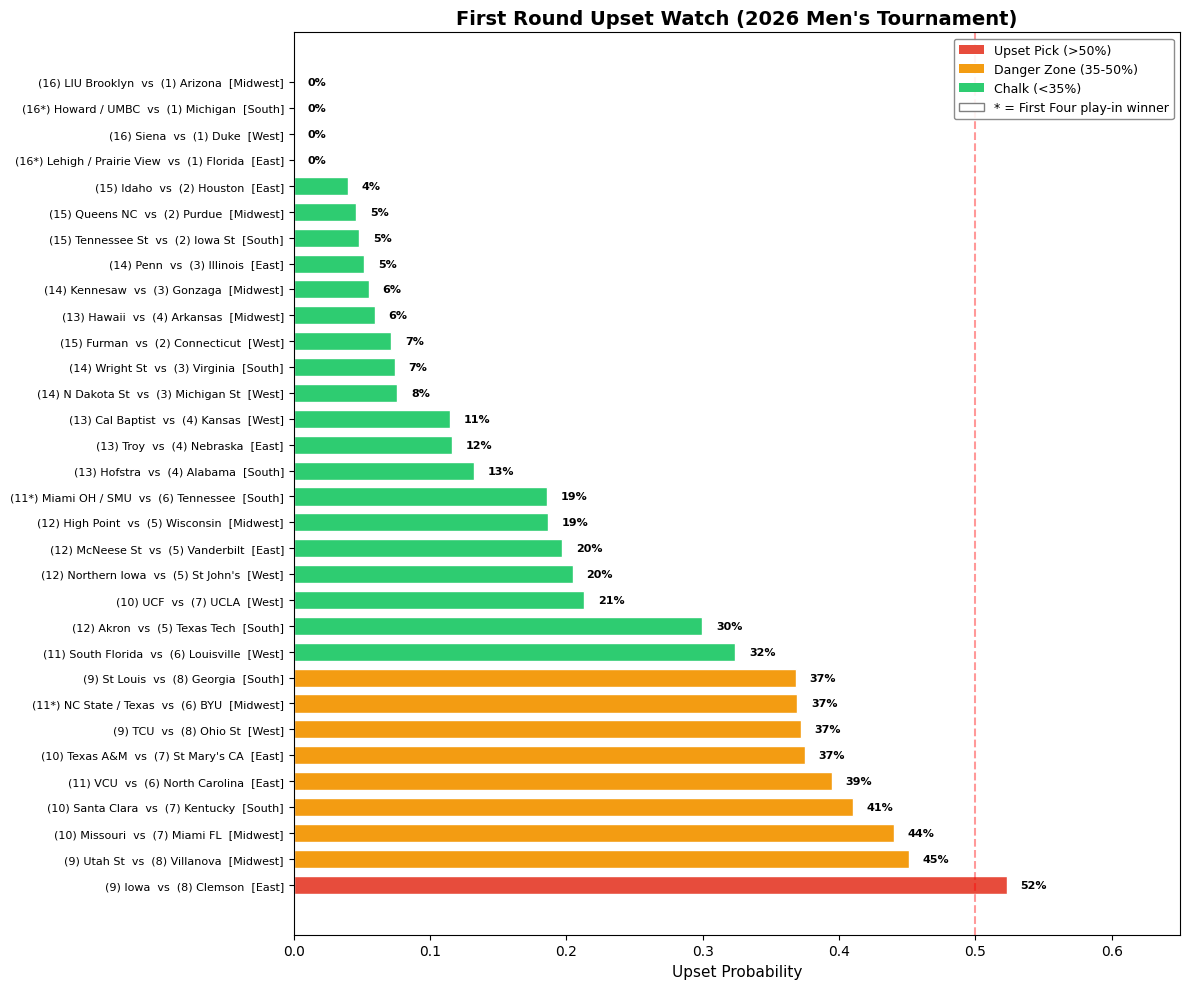

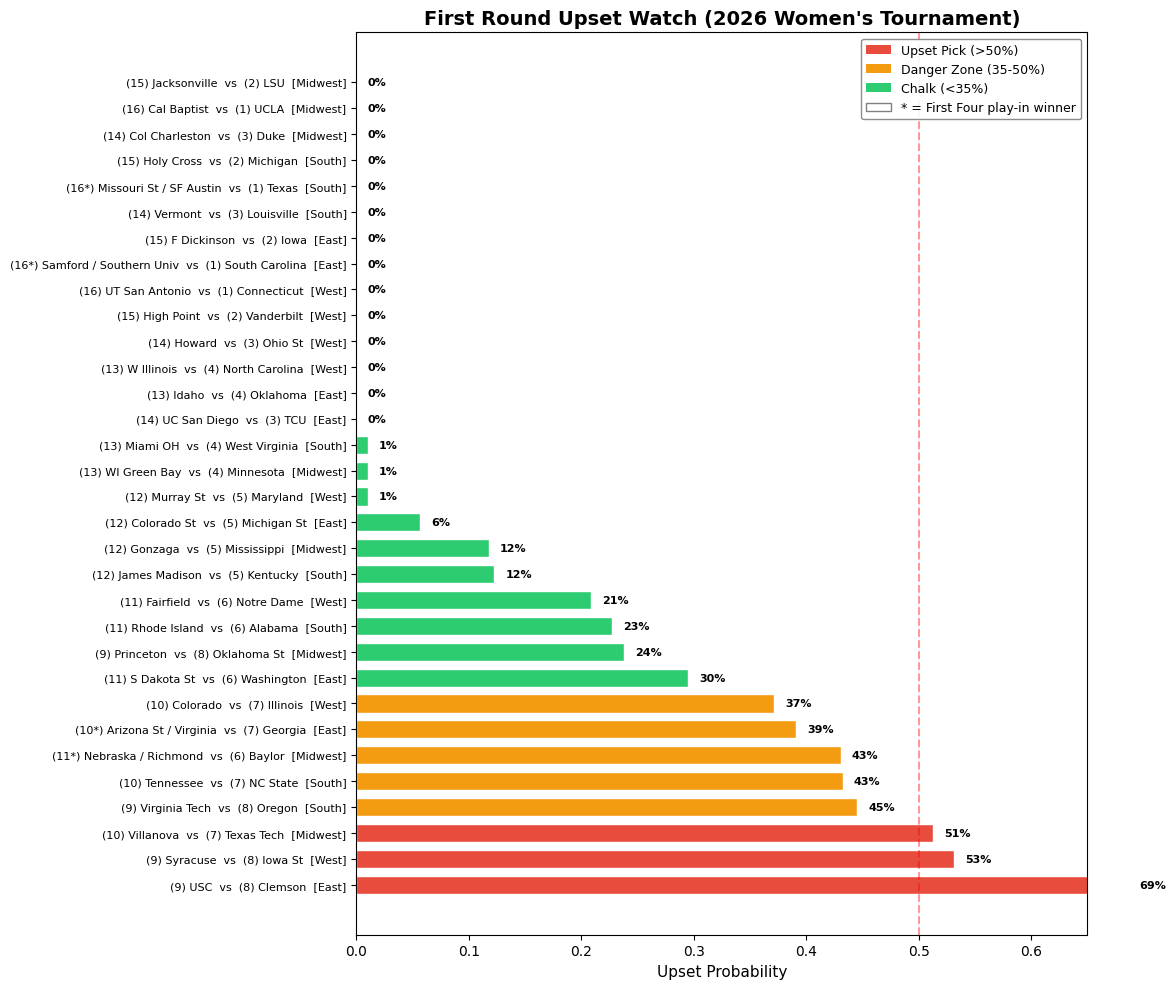

In [ ]:
# ── VIZ 6: First Round Upset Watch — Men's + Women's ─────────────────────────
from collections import defaultdict


def build_first_round(seed_file, pred_df):
    seed_data = pd.read_csv(f"{data_dir}{seed_file}")
    s26g = seed_data[seed_data["Season"] == 2026].copy()
    s26g["seed_num"] = s26g["Seed"].apply(lambda x: int(x[1:3]))
    s26g["region"] = s26g["Seed"].apply(lambda x: x[0])
    s26g["is_ff"] = s26g["Seed"].str.contains("[ab]", regex=True)
    s26g = s26g.merge(all_teams, on="TeamID")

    pred_map = {}
    for _, r in pred_df.iterrows():
        pred_map[(int(r["T1"]), int(r["T2"]))] = r["Pred"]

    matchups = []
    rnames = {"W": "West", "X": "East", "Y": "South", "Z": "Midwest"}
    for region in sorted(s26g["region"].unique()):
        rg = s26g[s26g["region"] == region].sort_values("seed_num")
        for hi, lo in [
            (1, 16),
            (2, 15),
            (3, 14),
            (4, 13),
            (5, 12),
            (6, 11),
            (7, 10),
            (8, 9),
        ]:
            favs = rg[rg["seed_num"] == hi]
            dogs = rg[rg["seed_num"] == lo]
            if len(favs) == 0 or len(dogs) == 0:
                continue

            fav_list = favs["TeamID"].values
            dog_list = dogs["TeamID"].values
            fav_names = favs["TeamName"].values
            dog_names = dogs["TeamName"].values
            fav_ff = favs["is_ff"].any()
            dog_ff = dogs["is_ff"].any()

            probs = []
            for fid in fav_list:
                for did in dog_list:
                    t1, t2 = min(fid, did), max(fid, did)
                    p = pred_map.get((t1, t2))
                    if p is None:
                        continue
                    fav_wp = p if t1 == fid else 1 - p
                    probs.append(fav_wp)

            if not probs:
                continue
            avg_fav_wp = sum(probs) / len(probs)

            if len(fav_names) > 1:
                fav_label = " / ".join(fav_names)
            else:
                fav_label = fav_names[0]
            if len(dog_names) > 1:
                dog_label = " / ".join(dog_names)
            else:
                dog_label = dog_names[0]

            matchups.append(
                {
                    "region": rnames.get(region, region),
                    "fav": fav_label,
                    "fav_seed": hi,
                    "fav_ff": fav_ff,
                    "dog": dog_label,
                    "dog_seed": lo,
                    "dog_ff": dog_ff,
                    "fav_wp": avg_fav_wp,
                    "upset_prob": 1 - avg_fav_wp,
                }
            )
    return pd.DataFrame(matchups)


def seed_label(seed, is_ff):
    return f"{seed}*" if is_ff else str(seed)


def plot_upset_watch(mdf, title, save_name):
    mdf = mdf.sort_values("upset_prob", ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    y = range(len(mdf))
    colors = [
        (
            "#e74c3c"
            if r["upset_prob"] > 0.5
            else "#f39c12" if r["upset_prob"] > 0.35 else "#2ecc71"
        )
        for _, r in mdf.iterrows()
    ]

    ax.barh(y, mdf["upset_prob"], color=colors, edgecolor="white", height=0.7)
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.4, linewidth=1.5)

    labels = []
    for _, r in mdf.iterrows():
        ds = seed_label(r["dog_seed"], r["dog_ff"])
        fs = seed_label(r["fav_seed"], r["fav_ff"])
        labels.append(f"({ds}) {r['dog']}  vs  ({fs}) {r['fav']}  [{r['region']}]")
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Upset Probability", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlim(0, 0.65)

    for i, (_, r) in enumerate(mdf.iterrows()):
        ax.text(
            r["upset_prob"] + 0.01,
            i,
            f"{r['upset_prob']:.0%}",
            va="center",
            fontsize=8,
            fontweight="bold",
        )

    legend_elements = [
        mpatches.Patch(facecolor="#e74c3c", label="Upset Pick (>50%)"),
        mpatches.Patch(facecolor="#f39c12", label="Danger Zone (35-50%)"),
        mpatches.Patch(facecolor="#2ecc71", label="Chalk (<35%)"),
        mpatches.Patch(
            facecolor="white", edgecolor="gray", label="* = First Four play-in winner"
        ),
    ]
    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=9,
        framealpha=0.9,
        edgecolor="gray",
    )
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches="tight")
    plt.show()


women = p26[~p26["men"]].copy()
men_matchups = build_first_round("MNCAATourneySeeds.csv", men)
women_matchups = build_first_round("WNCAATourneySeeds.csv", women)

plot_upset_watch(
    men_matchups,
    "First Round Upset Watch (2026 Men's Tournament)",
    "viz_upset_watch.png",
)
plot_upset_watch(
    women_matchups,
    "First Round Upset Watch (2026 Women's Tournament)",
    "viz_upset_watch_women.png",
)

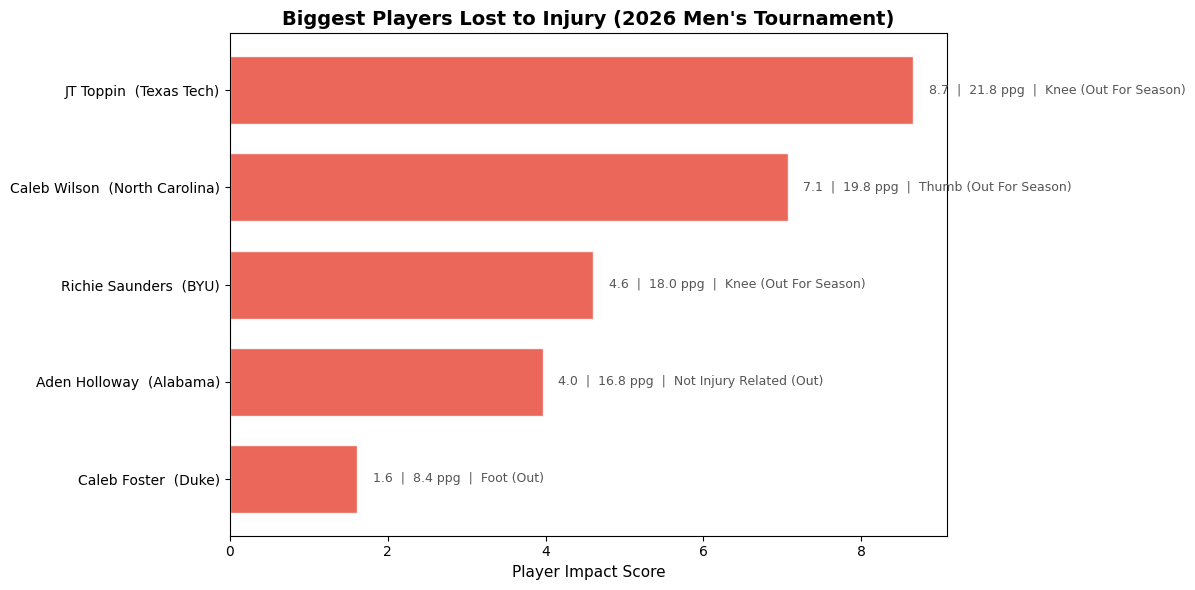

In [32]:
# ── VIZ 7: Top 10 Players Lost to Injury in the Tournament ──────────────────
impact_viz = pd.read_csv("impact.csv")
spellings_viz = pd.read_csv(f"{data_dir}MTeamSpellings.csv", encoding="latin-1")
spell_map_viz = dict(
    zip(spellings_viz["TeamNameSpelling"].str.lower(), spellings_viz["TeamID"])
)
spell_map_viz.update(
    {
        "arkansas pine bluff": 1115,
        "bethune cookman": 1126,
        "cal st. bakersfield": 1167,
        "illinois chicago": 1227,
        "louisiana lafayette": 1418,
        "louisiana monroe": 1419,
        "mississippi valley st.": 1290,
        "queens": 1474,
        "saint francis": 1383,
        "southeast missouri st.": 1369,
        "st. francis ny": 1383,
        "st. francis pa": 1384,
        "tarleton st.": 1470,
        "tennessee martin": 1404,
        "texas a&m commerce": 1477,
        "texas a&m corpus chris": 1394,
        "ut rio grande valley": 1410,
        "winston salem st.": 1445,
    }
)
impact_viz["TeamID"] = impact_viz["team"].str.lower().map(spell_map_viz)

m_seeds_viz = pd.read_csv(f"{data_dir}MNCAATourneySeeds.csv")
tourney_ids_2026 = set(m_seeds_viz[m_seeds_viz["Season"] == 2026]["TeamID"])

tourney_players = impact_viz[
    (impact_viz["Season"] == 2026) & (impact_viz["TeamID"].isin(tourney_ids_2026))
].copy()

injuries_viz = pd.read_csv("college-basketball-injury-report.csv")
injured_df = injuries_viz[injuries_viz["Status"].isin(["Out", "Out For Season"])].copy()
injured_map = dict(
    zip(
        injured_df["Player"].str.lower(),
        zip(injured_df["Injury"], injured_df["Status"]),
    )
)

tourney_players["injured"] = (
    tourney_players["player"].str.lower().isin(injured_map.keys())
)
injured_players = (
    tourney_players[tourney_players["injured"]]
    .sort_values("impact", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Get injury details
injured_players["injury_info"] = (
    injured_players["player"]
    .str.lower()
    .map(lambda x: injured_map.get(x, ("Unknown", "Out")))
)
injured_players["injury"] = injured_players["injury_info"].apply(lambda x: x[0])
injured_players["status"] = injured_players["injury_info"].apply(lambda x: x[1])

fig, ax = plt.subplots(figsize=(12, 6))
y = range(len(injured_players))
bars = ax.barh(
    y,
    injured_players["impact"],
    color="#e74c3c",
    edgecolor="white",
    height=0.7,
    alpha=0.85,
)

labels = [f"{r['player']}  ({r['team']})" for _, r in injured_players.iterrows()]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Player Impact Score", fontsize=11)
ax.set_title(
    "Biggest Players Lost to Injury (2026 Men's Tournament)",
    fontsize=14,
    fontweight="bold",
)

for i, (_, r) in enumerate(injured_players.iterrows()):
    ax.text(
        r["impact"] + 0.2,
        i,
        f"{r['impact']:.1f}  |  {r['ppg']:.1f} ppg  |  {r['injury']} ({r['status']})",
        va="center",
        fontsize=9,
        color="#555",
    )

ax.invert_yaxis()
plt.tight_layout()
plt.savefig("viz_top_injured.png", dpi=150, bbox_inches="tight")
plt.show()